In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
project_root = Path.cwd()

if project_root.name != "AI_Data_Insights_Generator":
    project_root = Path(r"C:\Users\LENOVO\AI_Data_Insights_Generator")

reports_dir = project_root / "reports"

business_insights_path = reports_dir / "business_insights.json"
final_report_path = reports_dir / "final_business_report.json"

print("Project root:", project_root)
print("Reports directory:", reports_dir)
print("Business insights:", business_insights_path)
print("Final report:", final_report_path)

print("\nBusiness insights exists:", business_insights_path.exists())
print("Final report exists:", final_report_path.exists())

Project root: C:\Users\LENOVO\AI_Data_Insights_Generator
Reports directory: C:\Users\LENOVO\AI_Data_Insights_Generator\reports
Business insights: C:\Users\LENOVO\AI_Data_Insights_Generator\reports\business_insights.json
Final report: C:\Users\LENOVO\AI_Data_Insights_Generator\reports\final_business_report.json

Business insights exists: True
Final report exists: True


In [2]:
# Load generated reports

with open(business_insights_path, "r", encoding="utf-8") as f:
    business_insights = json.load(f)

with open(final_report_path, "r", encoding="utf-8") as f:
    final_report = json.load(f)

print("Reports loaded successfully.")

print("\nBusiness insights sections:")
print(list(business_insights.keys()))

print("\nFinal report sections:")
print(list(final_report.keys()))

Reports loaded successfully.

Business insights sections:
['overall', 'top_risks', 'top_product_risks', 'recommendations', 'product_recommendations']

Final report sections:
['report_title', 'period', 'executive_summary', 'key_business_risks', 'critical_product_risks', 'business_recommendations', 'product_recommendations']


In [3]:
# Extract KPI metrics for the dashboard

overall = business_insights["overall"]

total_sales = overall["total_sales"]
total_profit = overall["total_profit"]
profit_margin = overall["profit_margin"]
return_rate = overall["return_rate"]

critical_risk_count = overall["critical_risk_count"]
warning_risk_count = overall["warning_risk_count"]

print("Dashboard KPIs")
print("=" * 40)

print(f"Total Sales:       ${total_sales:,.2f}")
print(f"Total Profit:      ${total_profit:,.2f}")
print(f"Profit Margin:     {profit_margin:.2f}%")
print(f"Return Rate:       {return_rate:.2f}%")
print(f"Critical Risks:    {critical_risk_count}")
print(f"Warning Risks:     {warning_risk_count}")

Dashboard KPIs
Total Sales:       $1,565,804.32
Total Profit:      $175,262.11
Profit Margin:     11.19%
Return Rate:       4.86%
Critical Risks:    3
Warning Risks:     1


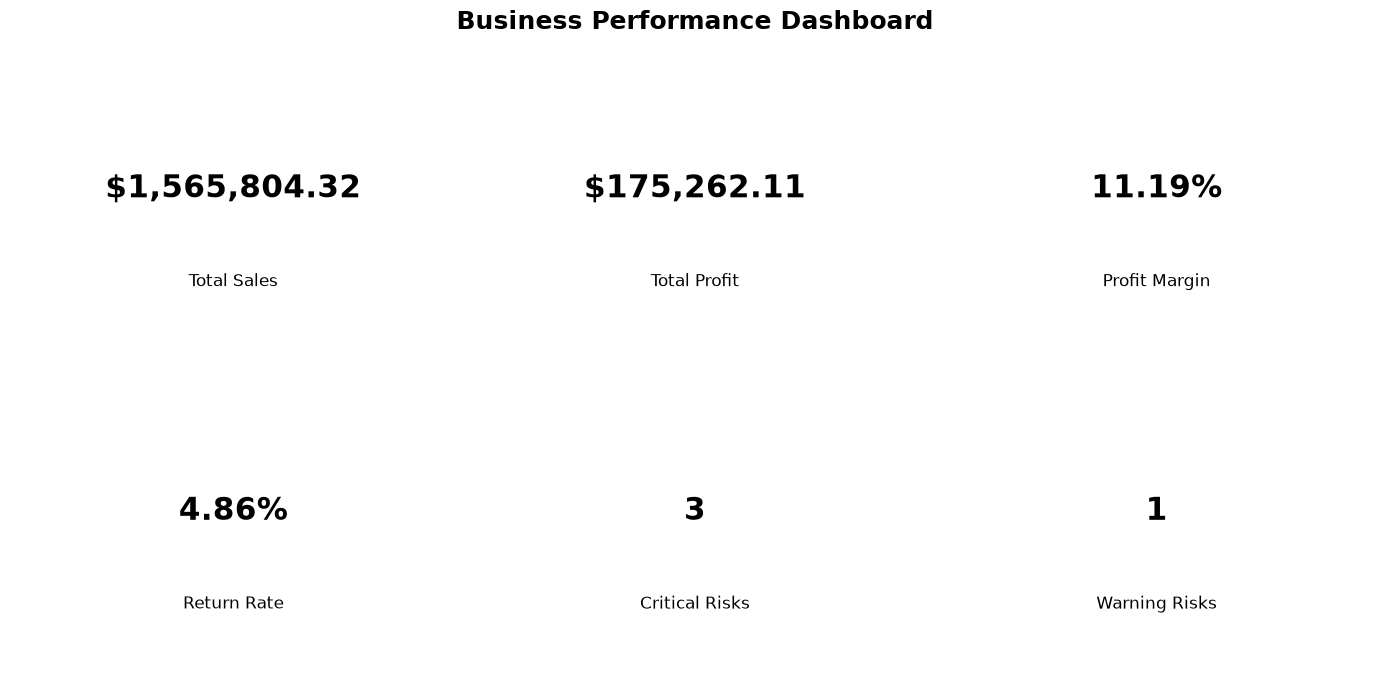

In [4]:
# KPI Dashboard

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("Business Performance Dashboard", fontsize=18, fontweight="bold")

kpis = [
    ("Total Sales", f"${total_sales:,.2f}"),
    ("Total Profit", f"${total_profit:,.2f}"),
    ("Profit Margin", f"{profit_margin:.2f}%"),
    ("Return Rate", f"{return_rate:.2f}%"),
    ("Critical Risks", str(critical_risk_count)),
    ("Warning Risks", str(warning_risk_count)),
]

for ax, (title, value) in zip(axes.flatten(), kpis):
    ax.text(
        0.5, 0.55,
        value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )
    
    ax.text(
        0.5, 0.25,
        title,
        ha="center",
        va="center",
        fontsize=12
    )
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

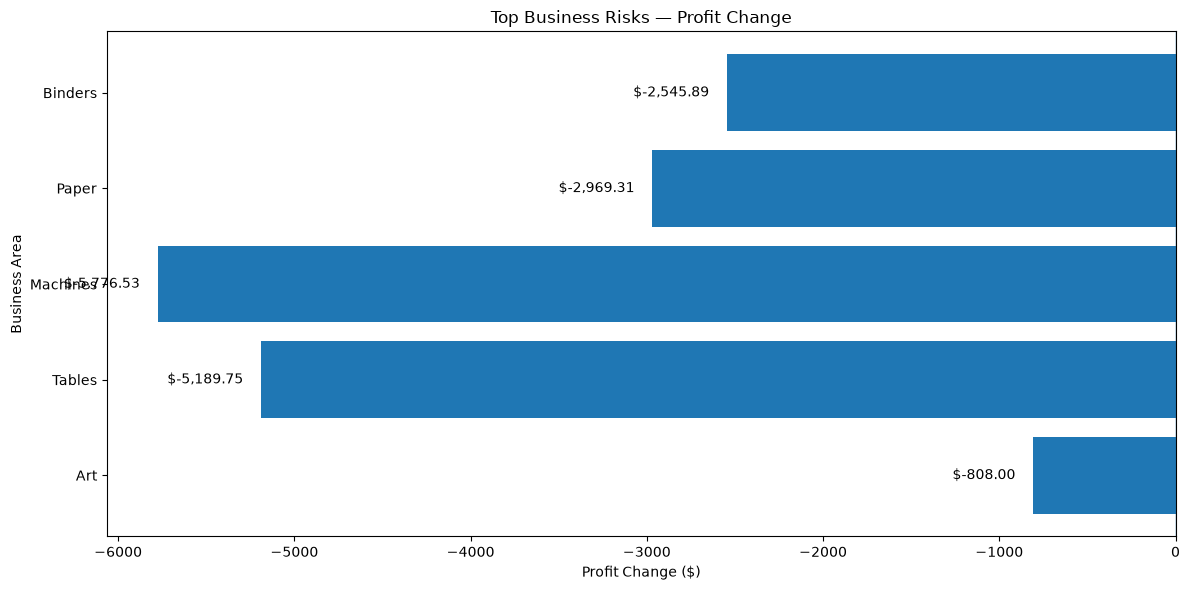

In [5]:
# Top Business Risks Visualization

top_risks = business_insights["top_risks"]

risk_areas = [risk["area"] for risk in top_risks]
risk_severities = [risk["severity"].upper() for risk in top_risks]

# Extract profit change from the messages
import re

profit_changes = []

for risk in top_risks:
    match = re.search(r"profit (?:declined|increased) by \$([\d,.-]+)", risk["message"])
    
    if match:
        value = float(match.group(1).replace(",", ""))
        
        if "declined" in risk["message"]:
            value = -value
            
        profit_changes.append(value)
    else:
        profit_changes.append(0)

plt.figure(figsize=(12, 6))

bars = plt.barh(risk_areas, profit_changes)

plt.axvline(0, linewidth=1)
plt.xlabel("Profit Change ($)")
plt.ylabel("Business Area")
plt.title("Top Business Risks — Profit Change")
plt.gca().invert_yaxis()

# Add values to bars
for bar, value in zip(bars, profit_changes):
    offset = 100 if value >= 0 else -100
    
    plt.text(
        value + offset,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.2f}",
        va="center",
        ha="left" if value >= 0 else "right"
    )

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd()

data_path = project_root / "data" / "SampleSuperstore_Cleaned.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset loaded successfully.
Shape: (5901, 22)
Columns: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'profit', 'payment_mode', 'returned', 'shipping_days']


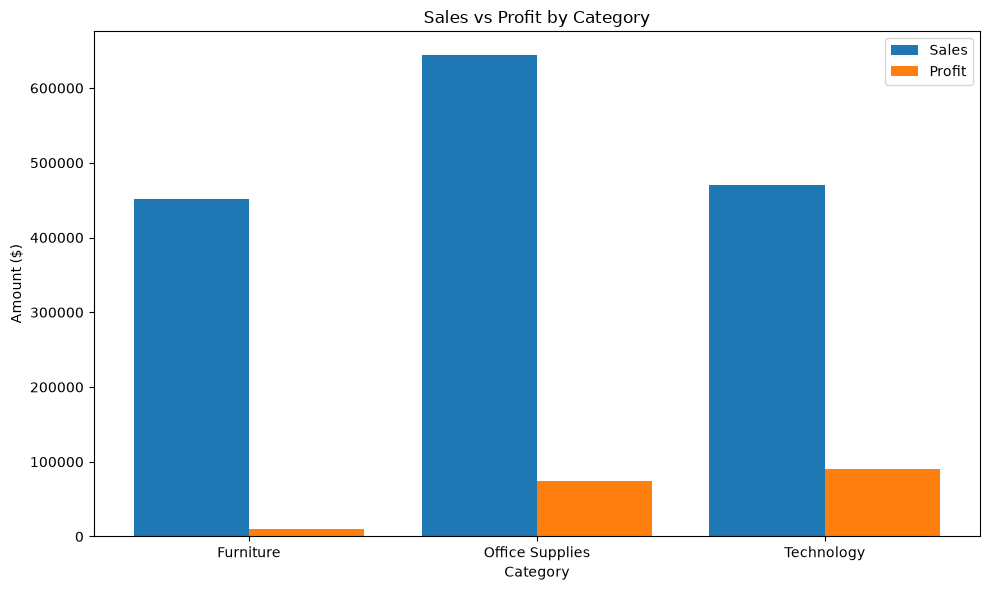

In [10]:
import matplotlib.pyplot as plt

# Category-level sales and profit
category_data = (
    df.groupby("category")
      .agg(
          Sales=("sales", "sum"),
          Profit=("profit", "sum")
      )
      .reset_index()
)

# Create chart
x = range(len(category_data))

plt.figure(figsize=(10, 6))

plt.bar(
    [i - 0.2 for i in x],
    category_data["Sales"],
    width=0.4,
    label="Sales"
)

plt.bar(
    [i + 0.2 for i in x],
    category_data["Profit"],
    width=0.4,
    label="Profit"
)

plt.xticks(x, category_data["category"])
plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount ($)")
plt.legend()

plt.tight_layout()
plt.show()

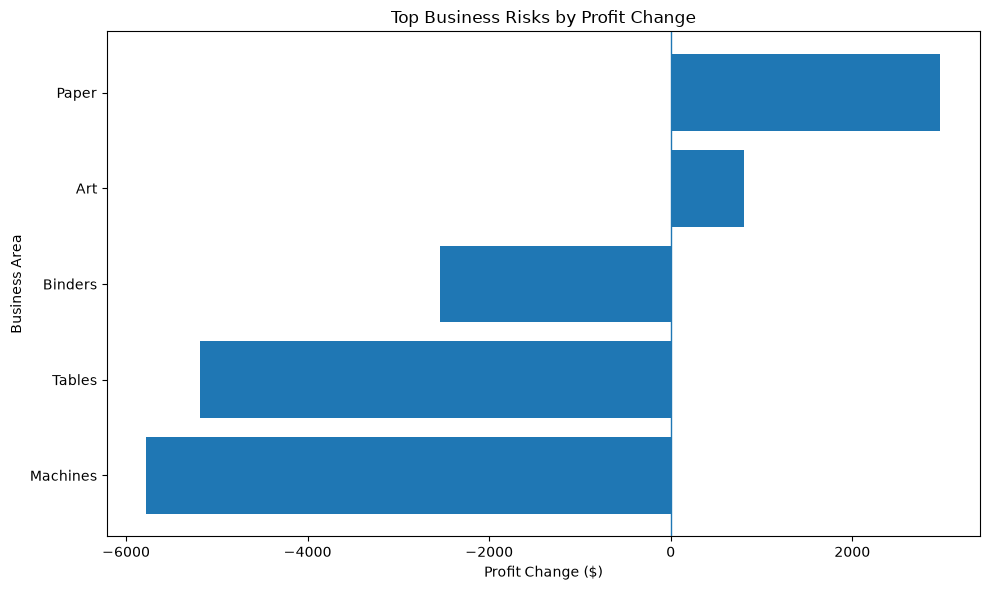

In [12]:
import matplotlib.pyplot as plt

risk_data = pd.DataFrame(business_insights["top_risks"])

# Extract profit change while preserving negative values
risk_data["profit_change"] = (
    risk_data["message"]
    .str.extract(r'profit (?:declined|increased) by \$(-?[\d,]+\.\d+)')[0]
    .str.replace(",", "")
    .astype(float)
)

# Profit declined → negative
risk_data.loc[
    risk_data["message"].str.contains("profit declined"),
    "profit_change"
] *= -1

# Sort for easier reading
risk_data = risk_data.sort_values("profit_change")

plt.figure(figsize=(10, 6))

plt.barh(
    risk_data["area"],
    risk_data["profit_change"]
)

plt.axvline(0, linewidth=1)

plt.title("Top Business Risks by Profit Change")
plt.xlabel("Profit Change ($)")
plt.ylabel("Business Area")

plt.tight_layout()
plt.show()

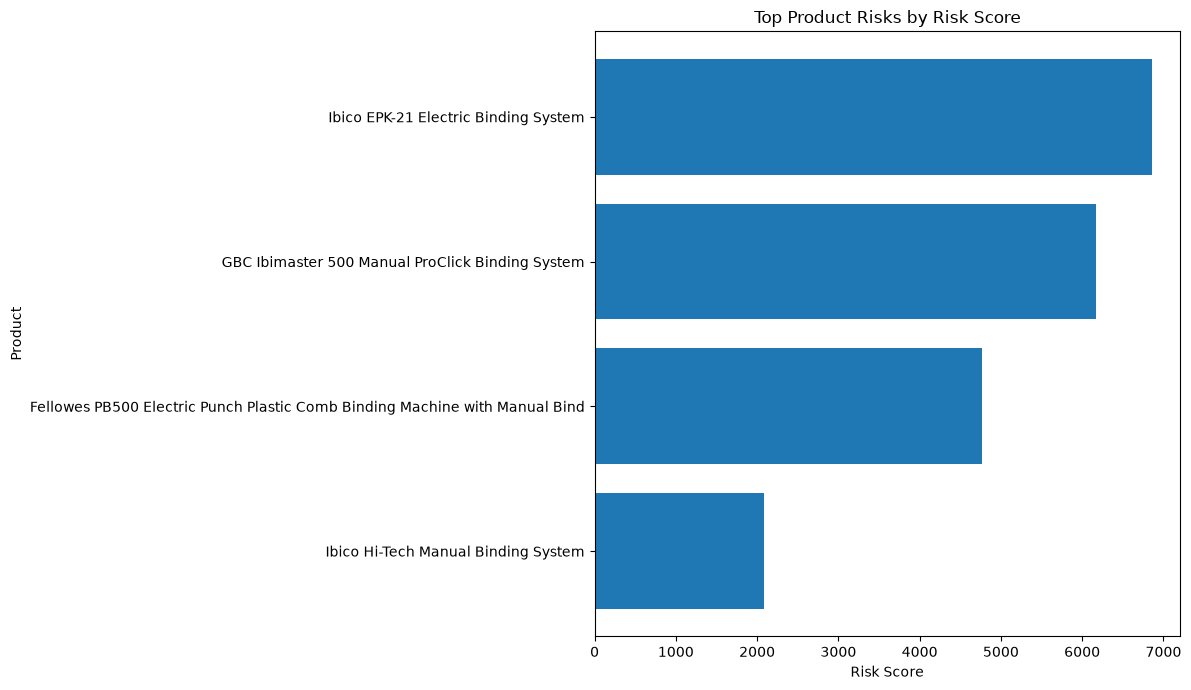

In [13]:
import matplotlib.pyplot as plt

# Get top product risks
product_risks = final_report["critical_product_risks"]

products = [item["product"] for item in product_risks]
risk_scores = [item["risk_score"] for item in product_risks]

# Reverse so the highest risk appears at the top
products = products[::-1]
risk_scores = risk_scores[::-1]

plt.figure(figsize=(12, 7))
plt.barh(products, risk_scores)

plt.xlabel("Risk Score")
plt.ylabel("Product")
plt.title("Top Product Risks by Risk Score")

plt.tight_layout()
plt.show()

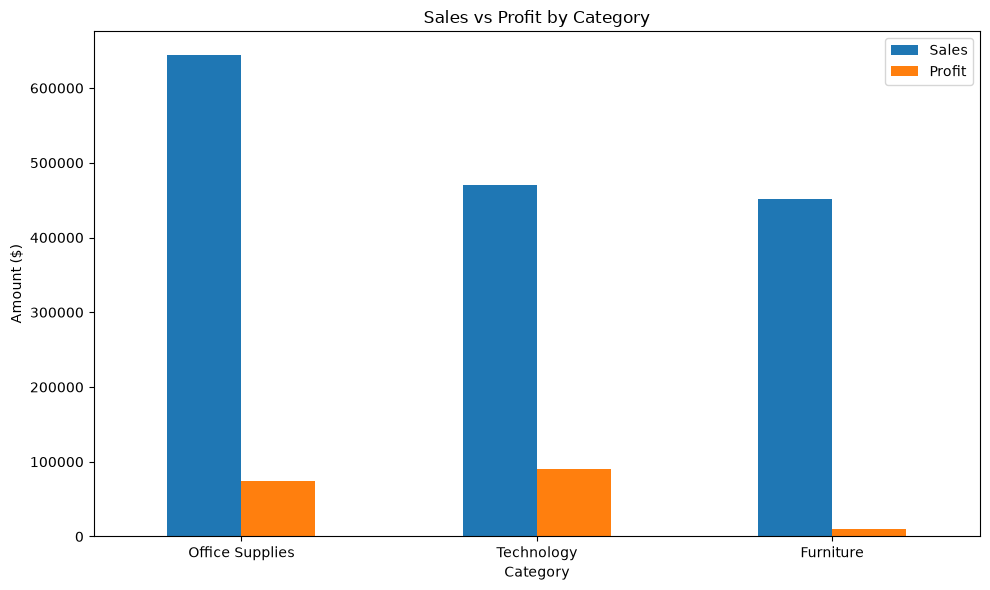

In [14]:
# Sales vs Profit by Category

category_summary = (
    df.groupby("category")[["sales", "profit"]]
      .sum()
      .sort_values("sales", ascending=False)
)

ax = category_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Sales vs Profit by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Amount ($)")
ax.legend(["Sales", "Profit"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

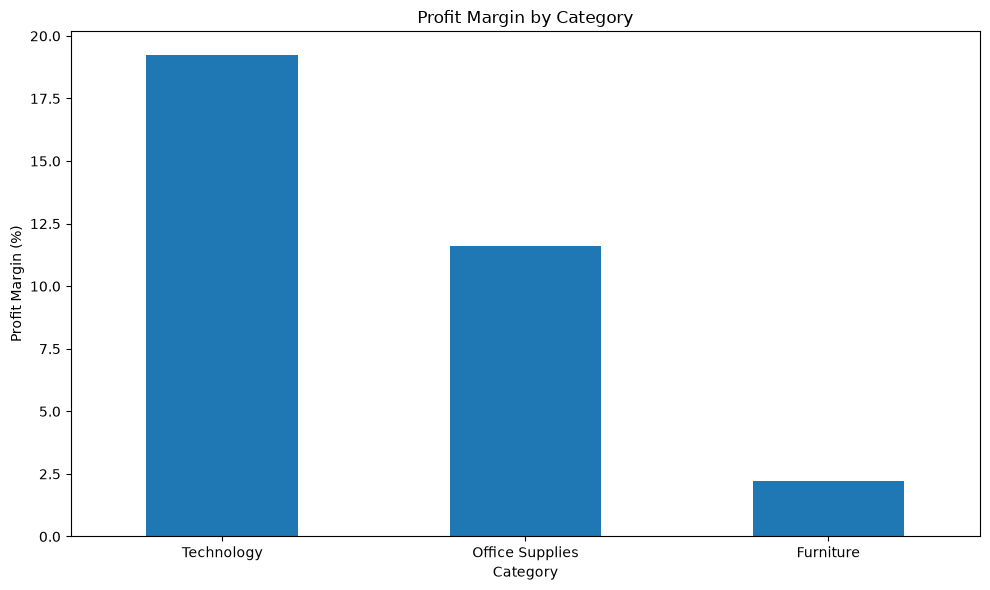

In [15]:
# Profit Margin by Category

category_margin = (
    df.groupby("category")
      .apply(lambda x: (x["profit"].sum() / x["sales"].sum()) * 100)
      .sort_values(ascending=False)
)

ax = category_margin.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Profit Margin by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

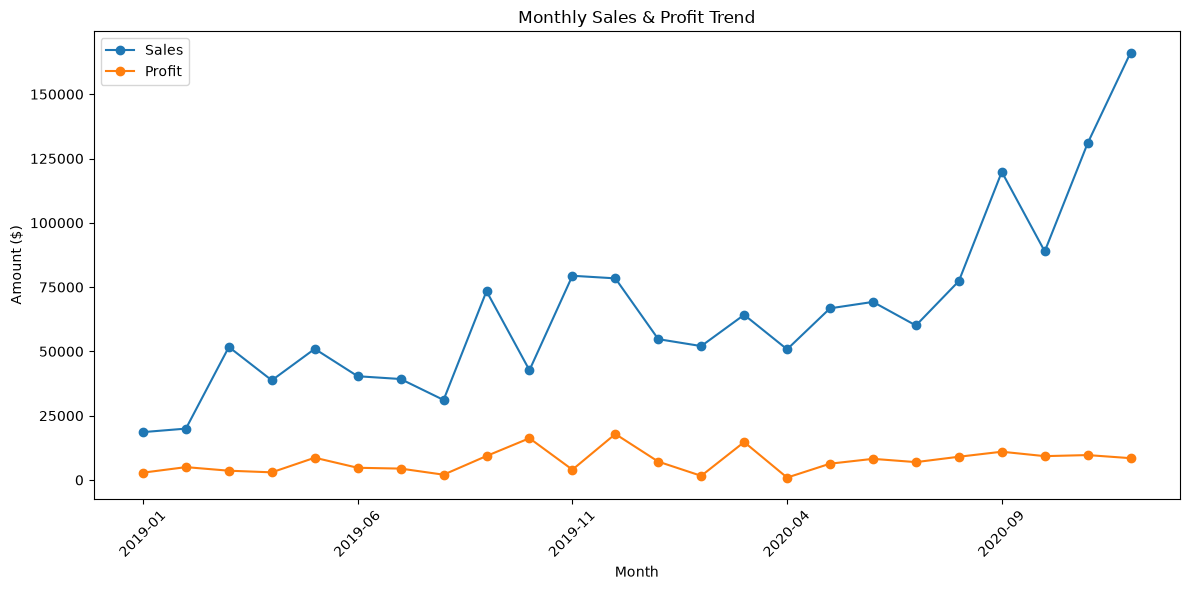

In [16]:
# Monthly Sales & Profit Trend

df["order_date"] = pd.to_datetime(df["order_date"])

monthly_summary = (
    df.groupby(df["order_date"].dt.to_period("M"))[["sales", "profit"]]
      .sum()
)

monthly_summary.index = monthly_summary.index.astype(str)

ax = monthly_summary.plot(
    kind="line",
    figsize=(12, 6),
    marker="o"
)

ax.set_title("Monthly Sales & Profit Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Amount ($)")
ax.legend(["Sales", "Profit"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
from pathlib import Path

project_root = Path(r"C:\Users\LENOVO\AI_Data_Insights_Generator")

print("Project:", project_root)
print("\nFiles and folders:")

for item in sorted(project_root.iterdir()):
    print("📁" if item.is_dir() else "📄", item.name)

Project: C:\Users\LENOVO\AI_Data_Insights_Generator

Files and folders:
📄      02_Data_Cleaning.ipynb
📄 .gitignore
📁 .ipynb_checkpoints
📄 01_Data_Exploration.ipynb
📄 03_Exploratory_Data_Analysis.ipynb
📄 04_Insight_Generation.ipynb
📄 05_Final_Report.ipynb
📄 06_Dashboard
📁 charts
📁 data
📁 notebooks
📄 README.md
📁 reports
📄 SampleSuperstore.csv
📁 screenshots
📁 src
📁 venv
